# Блок 2 — Обучение моделей

Двухэтапное обучение трёх моделей на подготовленных данных из блока 01.

> **Требование:** сначала запусти `01_data_preparation.ipynb`

## Стратегия

```
Stage 1 (pretrain)  →  Stage 2 (fine-tune)
[большой корпус]       [чистый нативный RU]
focal loss             cross-entropy + smoothing
lr=2e-5                lr=5e-6
```


In [2]:
import sys, os, json, gc

PROJECT_ROOT = '/kaggle/input/datasets/inexyy/se-analysis' if os.path.exists('/kaggle') else os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

WORKING_DIR = '/kaggle/working' if os.path.exists('/kaggle') else '../results'

import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk

print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU: Tesla T4
VRAM: 15.6 GB


## 1. Конфигурация

In [3]:
# ── Модели для ансамбля ────────────────────────────────────────────────────
MODELS = {
    'rubert': {
        'model_name': 'blanchefort/rubert-base-cased-sentiment',
        'stage1_dir': f'{WORKING_DIR}/models/rubert_s1',
        'stage2_dir': f'{WORKING_DIR}/models/rubert',
        's1_batch_size': 32, 's2_batch_size': 32,
        's1_gradient_accumulation_steps': 1, 's2_gradient_accumulation_steps': 1,
    },
    'xlmroberta': {
        'model_name': 'xlm-roberta-base',
        'stage1_dir': f'{WORKING_DIR}/models/xlmroberta_s1',
        'stage2_dir': f'{WORKING_DIR}/models/xlmroberta',
        's1_batch_size': 16, 's2_batch_size': 16,
        's1_gradient_accumulation_steps': 2, 's2_gradient_accumulation_steps': 2,
    },
    'rubert_tiny': {
        'model_name': 'cointegrated/rubert-tiny2',
        'stage1_dir': f'{WORKING_DIR}/models/rubert_tiny_s1',
        'stage2_dir': f'{WORKING_DIR}/models/rubert_tiny',
        's1_batch_size': 64, 's2_batch_size': 64,
        's1_gradient_accumulation_steps': 1, 's2_gradient_accumulation_steps': 1,
    },
    # ── Новые модели ──────────────────────────────────────────────────────
    'rubert_large': {
        # ai-forever (Sber AI) — ruBERT-large, мощная русскоязычная база
        'model_name': 'ai-forever/ruBert-large',
        'stage1_dir': f'{WORKING_DIR}/models/rubert_large_s1',
        'stage2_dir': f'{WORKING_DIR}/models/rubert_large',
        's1_batch_size': 8, 's2_batch_size': 8,
        's1_gradient_accumulation_steps': 4, 's2_gradient_accumulation_steps': 4,
    },
    'ruroberta_large': {
        # ai-forever (Sber AI) — ruRoBERTa-large, RoBERTa-архитектура на русском
        'model_name': 'ai-forever/ruRoberta-large',
        'stage1_dir': f'{WORKING_DIR}/models/ruroberta_large_s1',
        'stage2_dir': f'{WORKING_DIR}/models/ruroberta_large',
        's1_batch_size': 8, 's2_batch_size': 8,
        's1_gradient_accumulation_steps': 4, 's2_gradient_accumulation_steps': 4,
    },
    'aniemore_emotion': {
        # Aniemore — rubert-tiny2 дообученный на русских эмоциях (CEDR + RESD)
        'model_name': 'Aniemore/rubert-tiny2-russian-emotion-detection',
        'stage1_dir': f'{WORKING_DIR}/models/aniemore_emotion_s1',
        'stage2_dir': f'{WORKING_DIR}/models/aniemore_emotion',
        's1_batch_size': 64, 's2_batch_size': 64,
        's1_gradient_accumulation_steps': 1, 's2_gradient_accumulation_steps': 1,
    },
    'seara_goem': {
        # seara — DeepPavlov rubert-base дообученный на GoEmotions RU (28 классов → наш Stage 1)
        'model_name': 'seara/rubert-base-cased-russian-emotion-detection-ru-go-emotions',
        'stage1_dir': f'{WORKING_DIR}/models/seara_goem_s1',
        'stage2_dir': f'{WORKING_DIR}/models/seara_goem',
        's1_batch_size': 32, 's2_batch_size': 32,
        's1_gradient_accumulation_steps': 1, 's2_gradient_accumulation_steps': 1,
    },
}

# ── Гиперпараметры обучения ────────────────────────────────────────────────
S1_EPOCHS    = 3;  S1_LR = 2e-5;  S1_LOSS = 'focal';  S1_GAMMA = 2.0
S2_EPOCHS    = 3;  S2_LR = 5e-6;  S2_LOSS = 'ce';     S2_SMOOTHING = 0.05
MAX_LENGTH   = 128
FP16         = True
SEED         = 42

# ── Использовать аугментированные данные из блока 01 ──────────────────────
USE_AUGMENTED = True   # False — использовать необогащённые датасеты

# ── Какие модели обучать ───────────────────────────────────────────────────
TRAIN_FLAGS = {
    'rubert':           False,
    'xlmroberta':       False,
    'rubert_tiny':      False,
    'rubert_large':     False,
    'ruroberta_large':  False,
    'aniemore_emotion': False,
    'seara_goem':       True,
}

print('Конфигурация загружена')


Конфигурация загружена


## 2. Загрузка подготовленных данных

In [4]:
# ── Копирование данных из read-only input в WORKING_DIR ──────────────────────
# /kaggle/input/ — read-only, load_from_disk создаёт temp-файлы рядом с данными.
# Копируем в /kaggle/working/ один раз, дальше берём оттуда.

import shutil

_DATA_DIR = f'{PROJECT_ROOT}/data'

def _ensure_local(name):
    local = f'{WORKING_DIR}/{name}'
    if os.path.isdir(local):
        return local
    src = f'{_DATA_DIR}/{name}'
    if os.path.isdir(src):
        print(f'  Копируем {name} → {local} ...')
        shutil.copytree(src, local)
        print(f'  ✓ {name}')
        return local
    raise FileNotFoundError(f'{name} не найден ни в WORKING_DIR, ни в {src}')

print('Подготовка данных:')
for _n in ['stage1_data', 'stage1_data_augmented', 'stage2_data', 'stage2_data_augmented']:
    _ensure_local(_n)
print('Готово.')

Подготовка данных:
  Копируем stage1_data → /kaggle/working/stage1_data ...
  ✓ stage1_data
  Копируем stage1_data_augmented → /kaggle/working/stage1_data_augmented ...
  ✓ stage1_data_augmented
  Копируем stage2_data → /kaggle/working/stage2_data ...
  ✓ stage2_data
  Копируем stage2_data_augmented → /kaggle/working/stage2_data_augmented ...
  ✓ stage2_data_augmented
Готово.


In [5]:
from src.data_loader import EKMAN_LABEL_NAMES, EKMAN_ID2LABEL

LABEL_NAMES = EKMAN_LABEL_NAMES
NUM_LABELS  = len(LABEL_NAMES)
SEED = 42

S1_PATH = _ensure_local('stage1_data_augmented' if USE_AUGMENTED else 'stage1_data')
S2_PATH = _ensure_local('stage2_data_augmented' if USE_AUGMENTED else 'stage2_data')

print(f'Загружаем Stage-1: {S1_PATH}')
print(f'Загружаем Stage-2: {S2_PATH}')

stage1_ds = load_from_disk(S1_PATH)
stage2_ds = load_from_disk(S2_PATH)

print(f'\nStage-1:')
for split in stage1_ds:
    print(f'  {split:12s}: {len(stage1_ds[split]):,}')

print(f'\nStage-2:')
for split in stage2_ds:
    print(f'  {split:12s}: {len(stage2_ds[split]):,}')

import pandas as pd
df = stage1_ds['train'].to_pandas()
print('\nРаспределение Stage-1 train:')
for lid in range(NUM_LABELS):
    cnt = (df['label'] == lid).sum()
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>6,}')

Загружаем Stage-1: /kaggle/working/stage1_data_augmented
Загружаем Stage-2: /kaggle/working/stage2_data_augmented

Stage-1:
  train       : 84,377
  validation  : 13,171
  test        : 15,495

Stage-2:
  train       : 11,184
  validation  : 1,865
  test        : 2,194

Распределение Stage-1 train:
  anger       :  9,192
  disgust     :  9,192
  fear        :  9,192
  joy         : 15,173
  sadness     : 11,284
  surprise    : 15,172
  neutral     : 15,172


## 3. Обучение ансамбля (двухэтапное)

In [6]:
from src.trainer import train_two_stage

all_results = {}

for model_key, cfg in MODELS.items():
    if not TRAIN_FLAGS.get(model_key, False):
        print(f'\nПропускаем {model_key}')
        continue

    print(f'\n{"#"*60}')
    print(f'  Модель: {cfg["model_name"]}')
    print(f'  Stage1: {cfg["stage1_dir"]}')
    print(f'  Stage2: {cfg["stage2_dir"]}')
    print('#'*60)

    os.makedirs(cfg['stage1_dir'], exist_ok=True)
    os.makedirs(cfg['stage2_dir'], exist_ok=True)

    model, tokenizer, r1, r2 = train_two_stage(
        model_name=cfg['model_name'],
        stage1_dataset=stage1_ds,
        stage2_dataset=stage2_ds,
        stage1_dir=cfg['stage1_dir'],
        stage2_dir=cfg['stage2_dir'],
        num_labels=NUM_LABELS,
        label_names=LABEL_NAMES,
        s1_epochs=S1_EPOCHS, s1_batch_size=cfg['s1_batch_size'], s1_lr=S1_LR,
        s1_loss_type=S1_LOSS, s1_focal_gamma=S1_GAMMA, s1_use_class_weights=True,
        s1_gradient_accumulation_steps=cfg['s1_gradient_accumulation_steps'],
        s2_epochs=S2_EPOCHS, s2_batch_size=cfg['s2_batch_size'], s2_lr=S2_LR,
        s2_loss_type=S2_LOSS, s2_label_smoothing=S2_SMOOTHING,
        s2_gradient_accumulation_steps=cfg['s2_gradient_accumulation_steps'],
        max_length=MAX_LENGTH, fp16=FP16, seed=SEED,
    )

    all_results[model_key] = {'stage1': r1, 'stage2': r2}
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nВсе модели обучены.')



Пропускаем rubert

Пропускаем xlmroberta

Пропускаем rubert_tiny

Пропускаем rubert_large

Пропускаем ruroberta_large

Пропускаем aniemore_emotion

############################################################
  Модель: seara/rubert-base-cased-russian-emotion-detection-ru-go-emotions
  Stage1: /kaggle/working/models/seara_goem_s1
  Stage2: /kaggle/working/models/seara_goem
############################################################

TWO-STAGE TRAINING
  Base model : seara/rubert-base-cased-russian-emotion-detection-ru-go-emotions
  Stage 1    : 84,377 train examples  →  /kaggle/working/models/seara_goem_s1
  Stage 2    : 11,184 train examples  →  /kaggle/working/models/seara_goem

[STAGE 1] Pretrain on large mixed corpus...

Model : seara/rubert-base-cased-russian-emotion-detection-ru-go-emotions
Output: /kaggle/working/models/seara_goem_s1
Mode  : single-label | loss=focal
GPU   : Tesla T4


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/395 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Test results: /kaggle/working/models/seara_goem_s1 ---
              precision    recall  f1-score   support

       anger       0.77      0.71      0.74       210
     disgust       0.56      0.71      0.63        94
        fear       0.84      0.76      0.80       210
         joy       0.82      0.82      0.82       573
     sadness       0.88      0.83      0.85       353
    surprise       0.55      0.73      0.63        49
     neutral       0.86      0.88      0.87       705

    accuracy                           0.82      2194
   macro avg       0.75      0.78      0.76      2194
weighted avg       0.82      0.82      0.82      2194


Stage 1 F1-macro: 0.6070
Stage 2 F1-macro: 0.7616  (Δ = +0.1546)

Все модели обучены.


## 4. Результаты

=== Stage 1 vs Stage 2 ===
                              accuracy  f1_macro  f1_weighted
model                                                        
seara_goem — Stage 1            0.6287    0.6070       0.6336
seara_goem — Stage 2 (final)    0.8159    0.7616       0.8173


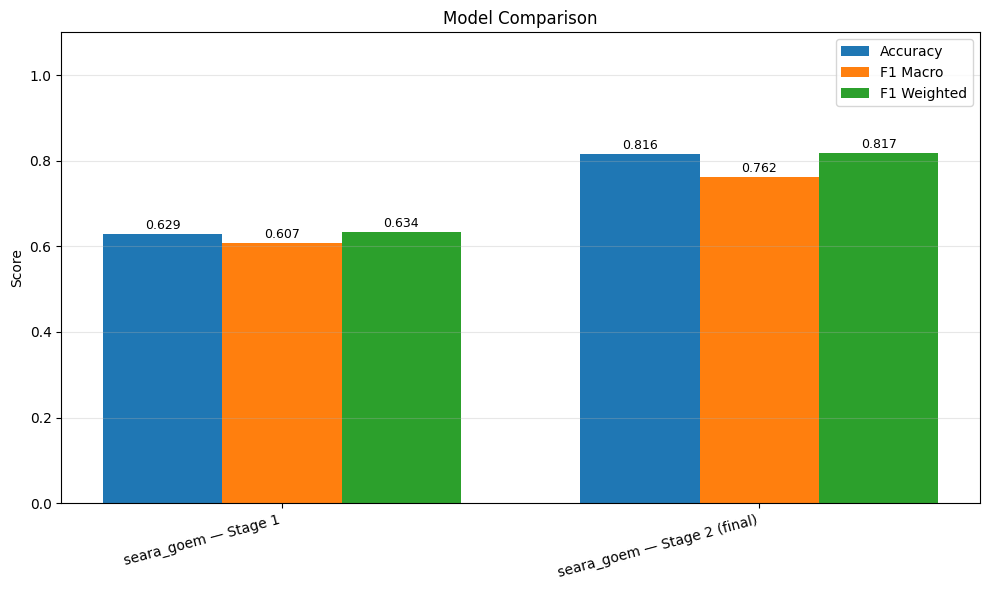

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.evaluation import evaluate_predictions, compare_models

rows = []
for model_key, cfg in MODELS.items():
    for stage, stage_dir in [('Stage 1', cfg['stage1_dir']), ('Stage 2 (final)', cfg['stage2_dir'])]:
        preds_path = os.path.join(stage_dir, 'test_preds.npy')
        if not os.path.exists(preds_path):
            continue
        preds  = np.load(os.path.join(stage_dir, 'test_preds.npy'))
        labels = np.load(os.path.join(stage_dir, 'test_labels.npy'))
        probs  = np.load(os.path.join(stage_dir, 'test_probs.npy'))
        m = evaluate_predictions(labels, preds, probs,
                                 model_name=f'{model_key} — {stage}',
                                 label_names=LABEL_NAMES)
        rows.append(m)

if rows:
    df = pd.DataFrame(rows).set_index('model')
    print('=== Stage 1 vs Stage 2 ===')
    print(df[['accuracy', 'f1_macro', 'f1_weighted']].round(4).to_string())

    compare_models(rows, save_path=f'{WORKING_DIR}/two_stage_comparison.png')


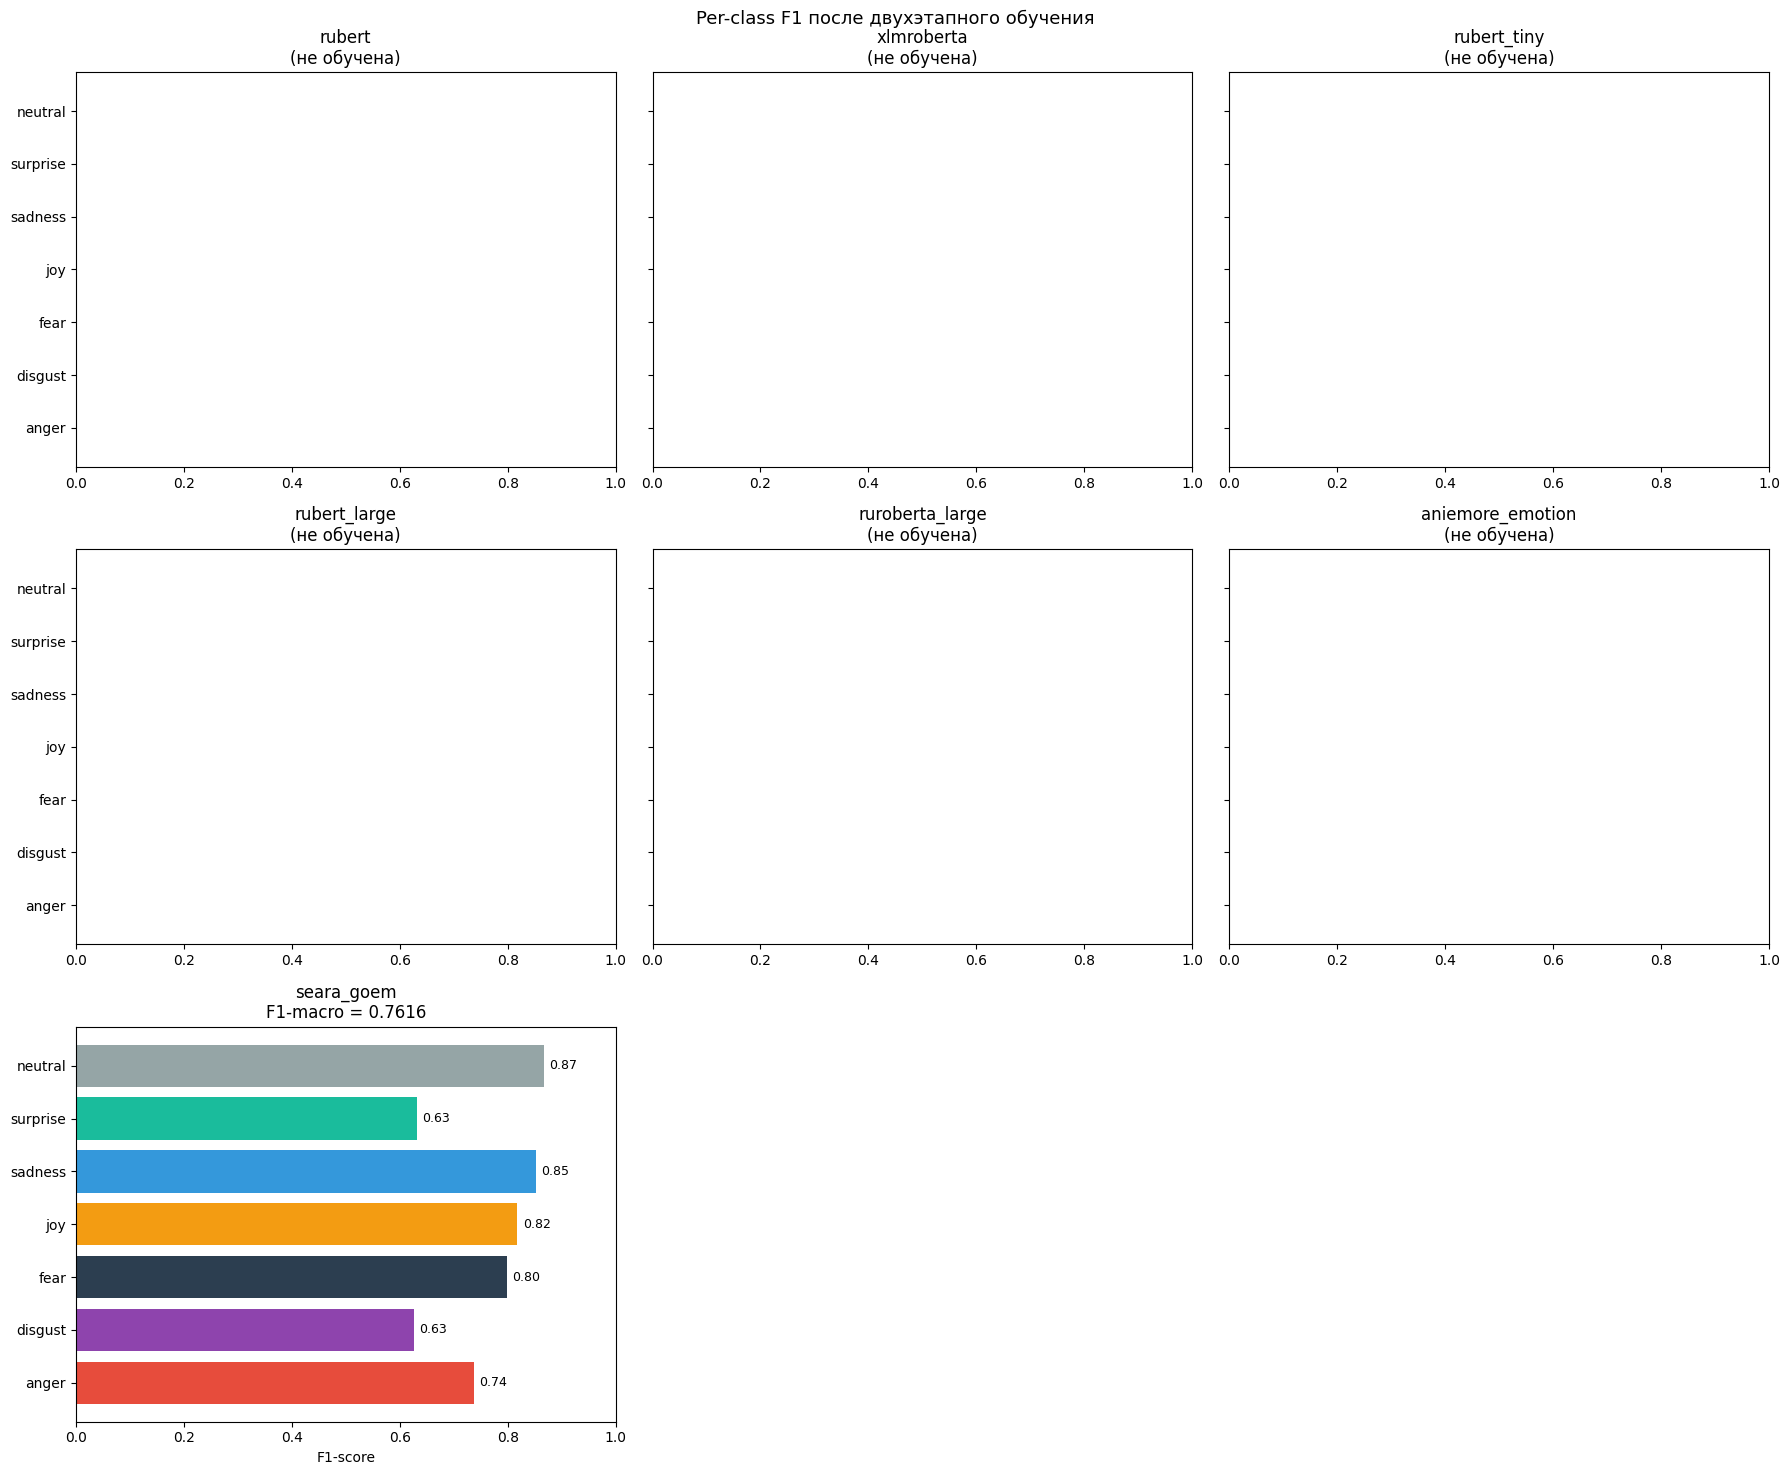

In [8]:
# Per-class F1 после Stage 2 для каждой модели
import math
n_models = len(MODELS)
ncols = 3
nrows = math.ceil(n_models / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), sharey=True)
axes_flat = axes.flatten() if n_models > 1 else [axes]

colors = ['#e74c3c','#8e44ad','#2c3e50','#f39c12','#3498db','#1abc9c','#95a5a6']

for ax, (model_key, cfg) in zip(axes_flat, MODELS.items()):
    stage2_dir = cfg['stage2_dir']
    if not os.path.exists(os.path.join(stage2_dir, 'test_preds.npy')):
        ax.set_title(f'{model_key}\n(не обучена)')
        continue

    preds  = np.load(os.path.join(stage2_dir, 'test_preds.npy'))
    labels = np.load(os.path.join(stage2_dir, 'test_labels.npy'))
    probs  = np.load(os.path.join(stage2_dir, 'test_probs.npy'))
    m = evaluate_predictions(labels, preds, probs, model_name=model_key, label_names=LABEL_NAMES)

    f1_per_class = [m.get(f'f1_{e}', 0) for e in LABEL_NAMES]
    ax.barh(LABEL_NAMES, f1_per_class, color=colors)
    ax.set_xlim(0, 1)
    ax.set_title(f'{model_key}\nF1-macro = {m["f1_macro"]:.4f}')
    for i, v in enumerate(f1_per_class):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
    ax.set_xlabel('F1-score')

# Скрываем пустые подграфики
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.suptitle('Per-class F1 после двухэтапного обучения', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/per_class_f1_two_stage.png', dpi=150, bbox_inches='tight')
plt.show()


## 4b. Сохранение предсказаний на train (для дистилляции в Block 3)

`train_probs.npy` — предсказания модели на Stage-2 **train** сплите.  
Используются как мягкие метки учителя при Knowledge Distillation в `03_ensemble.ipynb §6`.  
Загружать на HF Hub вместе с остальными `.npy`.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def _save_train_probs(model_key, cfg, dataset):
    stage2_dir = cfg['stage2_dir']
    out_path   = os.path.join(stage2_dir, 'train_probs.npy')

    if not os.path.exists(os.path.join(stage2_dir, 'config.json')):
        print(f'{model_key}: модель не обучена — пропускаем')
        return
    if os.path.exists(out_path):
        print(f'{model_key}: train_probs.npy уже есть ({np.load(out_path).shape})')
        return

    print(f'{model_key}: генерация train_probs.npy ({len(dataset["train"]):,} примеров) ...')
    tok   = AutoTokenizer.from_pretrained(stage2_dir)
    model = AutoModelForSequenceClassification.from_pretrained(stage2_dir).to(DEVICE).eval()

    texts = dataset['train']['text']
    bs    = cfg['s2_batch_size']
    probs_list = []

    with torch.no_grad():
        for i in range(0, len(texts), bs):
            enc = tok(list(texts[i:i+bs]), truncation=True, max_length=MAX_LENGTH,
                      padding=True, return_tensors='pt').to(DEVICE)
            probs_list.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())

    train_probs = np.concatenate(probs_list)
    np.save(out_path, train_probs)
    print(f'  ✓ {out_path}  shape={train_probs.shape}  '
          f'mean_max={train_probs.max(1).mean():.3f}')

    del model
    gc.collect()
    torch.cuda.empty_cache()


for model_key, cfg in MODELS.items():
    _save_train_probs(model_key, cfg, stage2_ds)


## 5. Сохранение конфигурации

In [9]:
ensemble_config = {
    'model_dirs': {
        k: v['stage2_dir'] for k, v in MODELS.items()
        if os.path.exists(os.path.join(v['stage2_dir'], 'config.json'))
    },
    'label_names': LABEL_NAMES,
    'training_strategy': 'two_stage',
    'stage1': {
        'epochs': S1_EPOCHS, 'lr': S1_LR,
        'loss': S1_LOSS, 'gamma': S1_GAMMA,
    },
    'stage2': {
        'epochs': S2_EPOCHS, 'lr': S2_LR,
        'loss': S2_LOSS, 'label_smoothing': S2_SMOOTHING,
        'corpus': 'cedr + brighter_hf + aniemore/resd',
    },
}

with open(f'{WORKING_DIR}/ensemble_config.json', 'w', encoding='utf-8') as f:
    json.dump(ensemble_config, f, ensure_ascii=False, indent=2)

with open(f'{WORKING_DIR}/label_names.json', 'w') as f:
    json.dump(LABEL_NAMES, f)

print('Конфигурация сохранена:')
print(json.dumps(ensemble_config, ensure_ascii=False, indent=2))


Конфигурация сохранена:
{
  "model_dirs": {
    "seara_goem": "/kaggle/working/models/seara_goem"
  },
  "label_names": [
    "anger",
    "disgust",
    "fear",
    "joy",
    "sadness",
    "surprise",
    "neutral"
  ],
  "training_strategy": "two_stage",
  "stage1": {
    "epochs": 3,
    "lr": 2e-05,
    "loss": "focal",
    "gamma": 2.0
  },
  "stage2": {
    "epochs": 3,
    "lr": 5e-06,
    "loss": "ce",
    "label_smoothing": 0.05,
    "corpus": "cedr + brighter_hf + aniemore/resd"
  }
}


## Итог

Все три модели обучены. Конфигурация сохранена в `ensemble_config.json`.

**Следующий шаг:** запустить `03_ensemble.ipynb` для ансамблирования и финальной оценки.
